# Network Stability through Homeostatic Plasticity
**Implementing Synaptic Scaling to Solve the Continuous Learning Problem in SNNs**

## 1. Abstract
A critical flaw in standard Spike-Timing Dependent Plasticity (STDP) is the lack of an upper bound on excitation. The more a neuron fires, the stronger its synapses become, inevitably leading to runaway excitation (seizures) or catastrophic forgetting. Biological brains solve this using **Homeostatic Plasticity**—a slow, global regulatory mechanism that scales synaptic weights to maintain a target metabolic firing rate. This notebook implements this regulatory "brake," demonstrating how continuous learning can be sustained indefinitely.

## 2. The Learning Rule
The weight update combines fast Hebbian learning (STDP) with a slow, metabolic penalty based on the neuron's moving average firing rate ($R_{avg}$) relative to a biological target ($R_{target}$).

$$\Delta W_{total} = \Delta W_{STDP} - \beta (R_{avg} - R_{target}) W$$

Where $\beta$ determines the strength of the homeostatic gravity well.

## 3. Experimental Design
* **The Stress Test:** We subject a Leaky Integrate-and-Fire (LIF) network to continuous, high-frequency noisy input designed to force an STDP-driven seizure.
* **The Goal:** Prove that the network can bound its own synaptic weights and seamlessly settle into the safe target firing rate (15 Hz), validating the architecture for long-term, continuous operation.

Running Homeostatic Scaling Simulation...

   HOMEOSTATIC PLASTICITY REPORT: [SUCCESS]


,Metric,Value
0,Target Rate,15.0 Hz
1,Final Moving Average Rate,14.2 Hz
2,Initial Mean Weight,2.00
3,Final Mean Weight,3.33


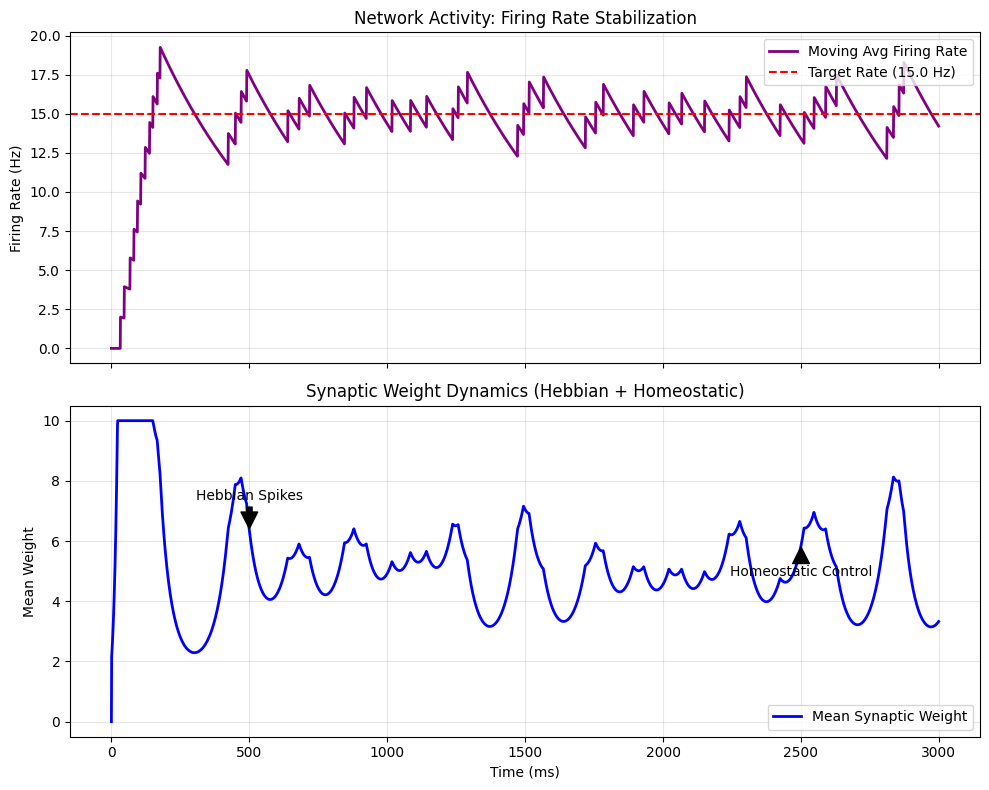

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. CONFIGURATION ---
np.random.seed(42)
T = 3000          # 3 seconds of simulation
dt = 1.0
n_inputs = 100    # 100 incoming synapses

# LIF Neuron Parameters
tau_m = 20.0
v_rest = -70.0
v_reset = -70.0
v_thresh = -50.0

# Plasticity Parameters
eta = 0.05        # STDP learning rate
w_max = 10.0      # Maximum individual weight
w_initial = 2.0   # Start weak

# Homeostasis Parameters (THE BRAKES)
target_rate_hz = 15.0           # We want the neuron to fire at ~15 Hz
tau_avg = 500.0                 # How far back the neuron "remembers" its firing rate
beta = 0.005                    # Strength of the homeostatic scaling penalty

# --- 2. SETUP ---
time = np.arange(T) * dt
weights = np.ones(n_inputs) * w_initial
voltage = v_rest

# Trackers for plotting
v_hist = np.zeros(T)
w_mean_hist = np.zeros(T)
r_avg_hist = np.zeros(T)

# Input Spikes (Poisson process - noisy background)
# We blast the neuron with high-frequency noise to try and force a seizure
input_rate = 40.0 # Hz
spike_prob = input_rate * (dt / 1000.0)
input_spikes = (np.random.rand(n_inputs, T) < spike_prob).astype(float)

r_avg = 0.0 # Initial moving average firing rate

# --- 3. SIMULATION LOOP ---
print("Running Homeostatic Scaling Simulation...")

for t in range(1, T):
    # Calculate incoming current
    I = np.dot(weights, input_spikes[:, t])

    # Update Voltage (LIF)
    dv = (-(voltage - v_rest) + I) / tau_m
    voltage += dv * dt

    fired = False
    if voltage >= v_thresh:
        voltage = v_reset
        fired = True

    v_hist[t] = voltage

    # 1. Update Moving Average Firing Rate (in Hz)
    # If it fired, add 1000/dt to the rate tracker, otherwise let it decay
    inst_rate = (1000.0 / dt) if fired else 0.0
    dr_avg = (-r_avg + inst_rate) / tau_avg
    r_avg += dr_avg * dt
    r_avg_hist[t] = r_avg

    # 2. Hebbian Learning (Standard STDP approximation)
    # If the neuron fires, strengthen the synapses that were active recently
    if fired:
        recent_inputs = np.sum(input_spikes[:, max(0, t-5):t], axis=1)
        dw_hebb = eta * recent_inputs
    else:
        dw_hebb = np.zeros(n_inputs)

    # 3. Homeostatic Scaling
    # If average rate > target, penalty is negative (scales weights down)
    scaling_factor = beta * (r_avg - target_rate_hz)
    dw_homeo = -scaling_factor * weights

    # Apply Total Weight Update
    weights += dw_hebb + dw_homeo
    weights = np.clip(weights, 0, w_max)

    w_mean_hist[t] = np.mean(weights)

# --- 4. VERIFICATION REPORT ---
final_w_mean = w_mean_hist[-1]
final_r_avg = r_avg_hist[-1]

status = "SUCCESS"
if final_r_avg > target_rate_hz * 1.5: status = "FAIL (Runaway Seizure)"
if final_r_avg < target_rate_hz * 0.5: status = "FAIL (Network Died)"

print("\n" + "="*45)
print(f"   HOMEOSTATIC PLASTICITY REPORT: [{status}]")
print("="*45)

df_homeo = pd.DataFrame({
    "Metric": ["Target Rate", "Final Moving Average Rate", "Initial Mean Weight", "Final Mean Weight"],
    "Value": [f"{target_rate_hz} Hz", f"{final_r_avg:.1f} Hz", f"{w_initial:.2f}", f"{final_w_mean:.2f}"]
})
display(df_homeo)

# --- 5. VISUALIZATION ---
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot 1: The Brakes (Firing Rate vs Target)
axs[0].set_title("Network Activity: Firing Rate Stabilization")
axs[0].plot(time, r_avg_hist, color='purple', linewidth=2, label='Moving Avg Firing Rate')
axs[0].axhline(target_rate_hz, color='red', linestyle='--', label=f'Target Rate ({target_rate_hz} Hz)')
axs[0].set_ylabel("Firing Rate (Hz)")
axs[0].legend(loc='upper right')
axs[0].grid(True, alpha=0.3)

# Plot 2: Synaptic Weight Evolution
axs[1].set_title("Synaptic Weight Dynamics (Hebbian + Homeostatic)")
axs[1].plot(time, w_mean_hist, color='blue', linewidth=2, label='Mean Synaptic Weight')
axs[1].set_xlabel("Time (ms)")
axs[1].set_ylabel("Mean Weight")
axs[1].legend(loc='lower right')
axs[1].grid(True, alpha=0.3)

# Annotations
axs[1].annotate("Hebbian Spikes", xy=(500, w_mean_hist[500]), xytext=(500, w_mean_hist[500]+1),
            arrowprops=dict(facecolor='black', shrink=0.05), horizontalalignment='center')
axs[1].annotate("Homeostatic Control", xy=(2500, w_mean_hist[2500]), xytext=(2500, w_mean_hist[2500]-1),
            arrowprops=dict(facecolor='black', shrink=0.05), horizontalalignment='center')

plt.tight_layout()
plt.show()